# BigStream alignment pipeline

In [1]:
import os
import json
import numpy as np
from pathlib import Path
from tifffile import imwrite as tiff_imwrite
import nrrd
import matplotlib.pyplot as plt
import zarr
import sys
from datetime import datetime

from bigstream.align import alignment_pipeline
import bigstream.transform as bst
from bigstream.piecewise_align import distributed_piecewise_alignment_pipeline
from bigstream.piecewise_transform import distributed_apply_transform
import copy

# Import helper function
BASE = Path(
    "/Users/jonathanboulanger-weill/Harvard University Dropbox/"
    "Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/"
)
sys.path.append(str(BASE))
import Bigstream_register_local_helpers as helpers


## Set local cluter 

In [ ]:
# Detect CPUs available (SLURM if present, else local)
cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))

# Are we using Dask-style parallelism? (set this manually in the notebook)
USING_DASK = True   # <- flip to False if running single-process code

# Threads per process (critical to avoid oversubscription on M3)
threads_per_proc = 1 if USING_DASK else cpus

keys = [
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",  # macOS Accelerate
    "NUMEXPR_NUM_THREADS",
    "ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS",
]

for k in keys:
    os.environ[k] = str(threads_per_proc)

print("CPUs available:", cpus)
print("USING_DASK:", USING_DASK)
print("Threads per process:", threads_per_proc)
print({k: os.environ.get(k) for k in keys})

# Set local cluster controls
CLUSTER_KWARGS = dict(
    cluster_type="local_cluster",
    n_workers=1,
    threads_per_worker=2,
    memory_limit="13GB",
)

CPUs available: 14
USING_DASK: True
Threads per process: 1
{'OMP_NUM_THREADS': '1', 'OPENBLAS_NUM_THREADS': '1', 'MKL_NUM_THREADS': '1', 'VECLIB_MAXIMUM_THREADS': '1', 'NUMEXPR_NUM_THREADS': '1', 'ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS': '1'}


## Load paths, spacing and stacks

In [ ]:
# -----------------------------
# Paths
# -----------------------------
MOVING_PATH = BASE / "data/exp1_110425/2p_stacks/2025-10-13_16-04-47_fish002_setup1_arena0_MW_preprocessed_data_repeat00_tile000_950nm_0_flippedxz_CARE.tif"
FIXED_PATH  = BASE / "data/exp1_110425/oct_confocal_stacks/fish2/prealigned/exp_001_fish2_s05-s09_montaged_MattesMI_GCaMP.tif"

MOVING_PATH_CONV = BASE / "data/exp1_110425/2p_stacks/2025-10-13_16-04-47_fish002_setup1_arena0_MW_preprocessed_data_repeat00_tile000_950nm_0_flippedxz_CARE_gf40.tif"
FIXED_PATH_CONV  = BASE / "data/exp1_110425/oct_confocal_stacks/fish2/prealigned/exp_001_fish2_s05-s09_montaged_MattesMI_GCaMP_gf50.tif"

OUT_PATH = BASE / "data/exp1_110425/Bigstream_output/montaged_stack"

tmpdir = Path(OUT_PATH) / "tmp_bigstream"
tmpdir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Identifiers
# -----------------------------
exp_id, fish, section = "exp_001", 2, "5-9"
run_id = f"{exp_id}_fish{fish}_section{section}"

# -----------------------------
# Spacing (Z, Y, X) in microns
# -----------------------------
FIXED_SPACING  = np.array([1.0, 0.621, 0.621], dtype=float)
MOVING_BASE    = np.array([0.396, 0.396, 0.396], dtype=float)

SCALE = 1.48  # tissue expansion
MOVING_SPACING = MOVING_BASE.copy()
MOVING_SPACING[1:] *= SCALE  # scale Y, X only

print(f"Fixed:  {FIXED_PATH}")
print(f"Moving: {MOVING_PATH}\n")
print("Fixed spacing:", FIXED_SPACING)
print("Moving spacing (scaled):", MOVING_SPACING)

# -----------------------------
# Load data (Z, Y, X convention)
# -----------------------------
fix  = helpers.load_tiff_float32(FIXED_PATH)
mov  = helpers.load_tiff_float32(MOVING_PATH)
fix_conv = helpers.load_tiff_float32(FIXED_PATH_CONV)
mov_conv = helpers.load_tiff_float32(MOVING_PATH_CONV)

print(f"Fixed:      {fix.shape}  {fix.dtype}")
print(f"Moving:     {mov.shape}  {mov.dtype}")
print(f"Fixed conv: {fix_conv.shape}  {fix_conv.dtype}")
print(f"Mov conv:   {mov_conv.shape}  {mov_conv.dtype}")

Fixed:  /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/oct_confocal_stacks/fish2/prealigned/exp_001_fish2_s05-s09_montaged_MattesMI_GCaMP.tif
Moving: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/2p_stacks/2025-10-13_16-04-47_fish002_setup1_arena0_MW_preprocessed_data_repeat00_tile000_950nm_0_flippedxz_CARE.tif

Fixed spacing: [1.    0.621 0.621]
Moving spacing (scaled): [0.396   0.58608 0.58608]
Fixed:      (45, 1024, 1024)  float32
Moving:     (283, 799, 799)  float32
Fixed conv: (45, 1024, 1024)  float32
Mov conv:   (283, 799, 799)  float32


## Make masks

Saved: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/Bigstream_output/montaged_stack/exp_001_fish2_section5-9_fix_mask.nrrd
Saved: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/Bigstream_output/montaged_stack/exp_001_fish2_section5-9_mov_mask.nrrd


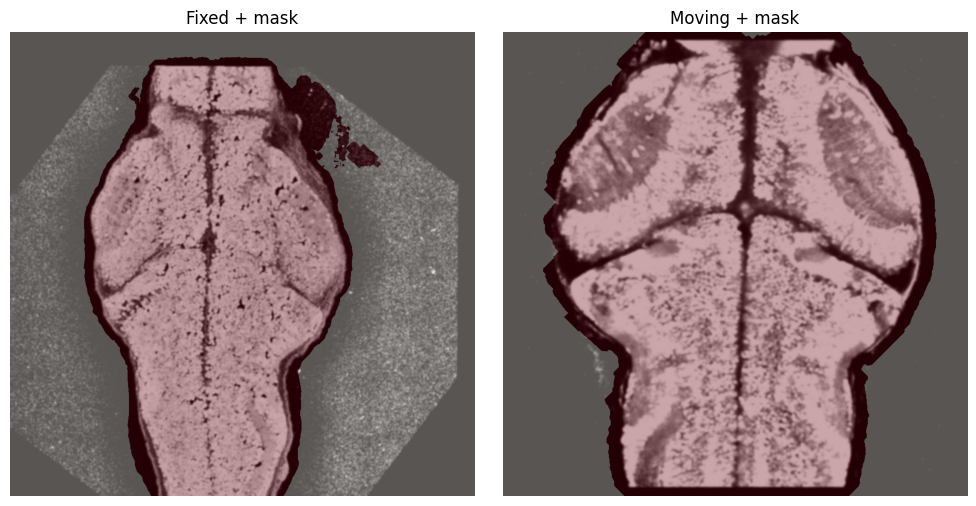

In [4]:
# -----------------------------
# Mask generation (RAW data)
# -----------------------------
fix_mask, fix_corr = helpers.homogenize_then_threshold_mask(
    fix, thresh=0.18, sigma_bg=40, dilate_iter=12
)
mov_mask, mov_corr = helpers.homogenize_then_threshold_mask(
    mov, thresh=0.30, sigma_bg=30, dilate_iter=24
)

# Save masks (convert ZYX → XYZ for NRRD compatibility)
fix_mask_xyz = np.transpose(fix_mask, (2, 1, 0))
mov_mask_xyz = np.transpose(mov_mask, (2, 1, 0))

fix_mask_path = helpers.mask_path(OUT_PATH, run_id, "fix_mask")
mov_mask_path = helpers.mask_path(OUT_PATH, run_id, "mov_mask")

nrrd.write(str(fix_mask_path), fix_mask_xyz)
nrrd.write(str(mov_mask_path), mov_mask_xyz)

print("Saved:", fix_mask_path)
print("Saved:", mov_mask_path)

# -----------------------------
# QC visualization
# -----------------------------
z_fix, z_mov = fix.shape[0] // 2, mov.shape[0] // 2

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(fix_corr[z_fix], cmap="gray")
ax[0].imshow(fix_mask[z_fix], cmap="Reds", alpha=0.35)
ax[0].set_title("Fixed + mask")
ax[0].axis("off")

ax[1].imshow(mov_corr[z_mov], cmap="gray")
ax[1].imshow(mov_mask[z_mov], cmap="Reds", alpha=0.35)
ax[1].set_title("Moving + mask")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## Global deform - Single section

In [ ]:
# -----------------------------
# Global alignment
# -----------------------------
steps_global_section = [
    ("rigid", dict(
        metric="MMI", metric_args={"numberOfHistogramBins": 32},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=1.5, minStep=5e-5, numberOfIterations=500),
        sampling="NONE",
        shrink_factors=(32, 16, 8, 4, 2, 1),
        smooth_sigmas=(48, 24, 12.0, 8.0, 4.0, 1.0),
        initial_condition="CENTER",
    )),
    ("affine", dict(
        metric="MMI", metric_args={"numberOfHistogramBins": 64},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=0.20, minStep=5e-7, numberOfIterations=2500),
        sampling="NONE",
        shrink_factors=(16, 8, 4, 2, 1),
        smooth_sigmas=(12.0, 6.0, 3.0, 1.0, 0.0),
    )),
    ("affine", dict(
        metric="ANC",
        optimizer="RSGD",
        optimizer_args=dict(learningRate=0.08, minStep=2e-7, numberOfIterations=1500),
        sampling="NONE",
        shrink_factors=(2, 1),
        smooth_sigmas=(0.4, 0.0),
    )),
]

global_transform = alignment_pipeline(
    fix=fix, mov=mov,
    fix_spacing=FIXED_SPACING, mov_spacing=MOVING_SPACING,
    fix_mask=fix_mask, mov_mask=mov_mask,
    steps=steps_global_section,
    return_format="independent",
    context="TEST",
)

print(f"Returned {len(global_transform)} transforms:",
      [getattr(t, 'shape', type(t)) for t in global_transform])

# -----------------------------
# Apply global transform (QC on convoluted data)
# -----------------------------
composed = bst.compose_transform_list(global_transform, FIXED_SPACING)

mov_aligned = bst.apply_transform(
    fix_conv, mov_conv,
    FIXED_SPACING, MOVING_SPACING,
    transform_list=[composed],
)

# QC overlay
z = fix.shape[0] // 2
plt.figure(figsize=(6, 6))
plt.imshow(fix[z], cmap="gray")
plt.imshow(mov_aligned[z], cmap="magma", alpha=0.35)
plt.title("Fixed + aligned moving (central z)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Global deform - Montaged stack

Returned 3 transforms: [(4, 4), (4, 4), (4, 4)]


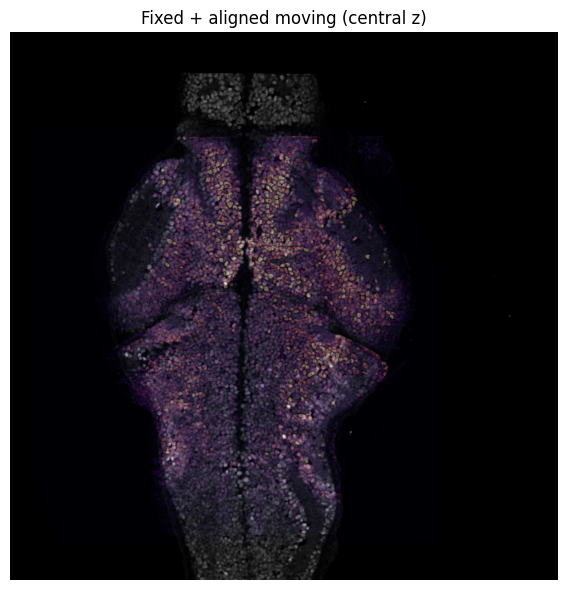

>> Building ImageJ 2-channel overlay (fixed, aligned moving)...
[save] Writing overlay TIFF: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/Bigstream_output/montaged_stack/exp_001_fish2_section5-9_20260311_131836_overlay_fixed_vs_global-aligned.tif


/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/tifffile/tifffile.py:1739: UserWarning: <tifffile.TiffWriter 'exp_001_fish2_se…bal-aligned.tif'> writing nonconformant BigTIFF ImageJ
  warnings.warn(


 saved: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/Bigstream_output/montaged_stack/exp_001_fish2_section5-9_20260311_131836_global_alignment_parameters.json


PosixPath('/Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/Bigstream_output/montaged_stack/exp_001_fish2_section5-9_20260311_131836_global_alignment_parameters.json')

In [5]:
# -----------------------------
# Global alignment (rigid → random → affine)
# -----------------------------
steps_global_montaged= [
    ("rigid", dict(
        metric="MMI", metric_args={"numberOfHistogramBins": 32},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=1.0, minStep=1e-4, numberOfIterations=600),
        sampling="RANDOM", sampling_percentage=0.20,
        shrink_factors=(32, 16, 8, 4, 2, 1),
        smooth_sigmas=(24.0, 12.0, 6.0, 3.0, 1.0, 0.0),
        initial_condition="CENTER",
    )),
    ("random", dict(
        random_iterations=8000, nreturn=5,
        max_translation=20.0, max_rotation=0.25,
        max_scale=1.03, max_shear=0.03,
        alignment_spacing=8.0,
        metric="MMI", metric_args={"numberOfHistogramBins": 24},
        sampling="RANDOM", sampling_percentage=0.10,
        shrink_factors=(16, 8, 4),
        smooth_sigmas=(6.0, 3.0, 1.5),
    )),
    ("affine", dict(
        metric="MMI", metric_args={"numberOfHistogramBins": 48},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=0.12, minStep=5e-7, numberOfIterations=1200),
        sampling="RANDOM", sampling_percentage=0.20,
        shrink_factors=(16, 8, 4, 2, 1),
        smooth_sigmas=(6.0, 3.0, 1.5, 0.5, 0.0),
    )),
]

global_transform = alignment_pipeline(
    fix=fix, mov=mov,
    fix_spacing=FIXED_SPACING, mov_spacing=MOVING_SPACING,
    fix_mask=fix_mask, mov_mask=mov_mask,
    steps=steps_global_montaged,
    return_format="independent",
    context="TEST",
)

print(f"Returned {len(global_transform)} transforms:",
      [getattr(t, 'shape', type(t)) for t in global_transform])

# -----------------------------
# Apply global transform (QC on convoluted data)
# -----------------------------
composed = bst.compose_transform_list(global_transform, FIXED_SPACING)

mov_aligned = bst.apply_transform(
    fix_conv, mov_conv,
    FIXED_SPACING, MOVING_SPACING,
    transform_list=[composed],
)

# QC middle section overlay
z = fix.shape[0] // 2
plt.figure(figsize=(6, 6))
plt.imshow(fix[z], cmap="gray")
plt.imshow(mov_aligned[z], cmap="magma", alpha=0.35)
plt.title("Fixed + aligned moving (central z)")
plt.axis("off")
plt.tight_layout()
plt.show()

# -----------------------------
# Build ImageJ 2-channel overlay
# -----------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(">> Building ImageJ 2-channel overlay (fixed, aligned moving)...")

fixed_zyx  = helpers.to_zyx(fix_conv).astype(np.float32, copy=False)
warped_zyx = helpers.to_zyx(mov_aligned).astype(np.float32, copy=False)

fixed_u16  = helpers._to_uint16_for_imagej(fixed_zyx)
warped_u16 = helpers._to_uint16_for_imagej(warped_zyx)

zmin = min(fixed_u16.shape[0], warped_u16.shape[0])
stacked = np.stack([fixed_u16[:zmin], warped_u16[:zmin]], axis=1)  # (Z, C, Y, X)
stacked = stacked[np.newaxis, ...]  # (T=1, Z, C=2, Y, X)

overlay_out = helpers.save_path(OUT_PATH, run_id, timestamp, "overlay_fixed_vs_global-aligned", "tif")
print(f"[save] Writing overlay TIFF: {overlay_out}")

tiff_imwrite(str(overlay_out), stacked, bigtiff=True, imagej=True, metadata={"axes": "TZCYX"},)

# -----------------------------
# Save metadata
# -----------------------------
meta = {
    "run_id": run_id,
    "timestamp": run_id,
    "fixed_path": str(FIXED_PATH),
    "moving_path": str(MOVING_PATH),
    "fixed_spacing_zyx_um": helpers.sanitize_for_json(FIXED_SPACING),
    "moving_spacing_zyx_um": helpers.sanitize_for_json(MOVING_SPACING),
    "global_steps": helpers.sanitize_for_json(steps_global_montaged),
}
helpers.write_json(OUT_PATH, run_id, timestamp, "global_alignment_parameters", meta)

## Piecewise alignment steps : single step

In [ ]:
# ============================================================
# PASS 1 (coarse / global+local): large blocks
# ============================================================

PIECEWISE_STEPS_PASS1_LARGE = [
    ("random", dict(
        random_iterations=6000, nreturn=5,
        max_translation=22.0, max_rotation=0.07,
        max_scale=1.008, max_shear=0.01,
        alignment_spacing=6.0,
        metric="MMI", metric_args={"numberOfHistogramBins": 16},
        sampling="RANDOM", sampling_percentage=0.40,
        shrink_factors=(2, 1), smooth_sigmas=(1.8, 0.0),
    )),
    ("affine", dict(
        metric="MMI", metric_args={"numberOfHistogramBins": 16},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=0.02, minStep=5e-7, numberOfIterations=200),
        sampling="RANDOM", sampling_percentage=0.25,
        shrink_factors=(4, 2, 1), smooth_sigmas=(2.0, 1.0, 0.0),
        initial_condition="IDENTITY",
    )),
]
BLOCKSIZE_PASS1, OVERLAP_PASS1 = (320, 320, 320), 0.35

# -----------------------------
# Global affine (4x4 matrix)
# -----------------------------
global_affine = composed
assert isinstance(global_affine, np.ndarray) and global_affine.shape == (4, 4)

# -----------------------------
# Run piecewise refinement (convoluted volumes)
# -----------------------------
local_stage1 = distributed_piecewise_alignment_pipeline(
    fix=fix_conv,
    mov=mov_conv,
    fix_spacing=FIXED_SPACING,
    mov_spacing=MOVING_SPACING,
    steps=PIECEWISE_STEPS_PASS1_LARGE,
    blocksize=BLOCKSIZE_PASS1,
    overlap=OVERLAP_PASS1,
    fix_mask=fix_mask,
    mov_mask=mov_mask,
    static_transform_list=[global_affine],
    rebalance_for_missing_neighbors=True,
    cluster_kwargs=copy.deepcopy(CLUSTER_KWARGS),
)

# -----------------------------
# Apply global + local transform
# -----------------------------
aligned_1step = distributed_apply_transform(
    fix_zarr=fix_conv,
    mov_zarr=mov_conv,
    fix_spacing=FIXED_SPACING,
    mov_spacing=MOVING_SPACING,
    transform_list=[global_affine, local_stage1],
    blocksize=BLOCKSIZE_PASS1,
    overlap=OVERLAP_PASS1,
    temporary_directory=str(tmpdir),
    cluster_kwargs=copy.deepcopy(CLUSTER_KWARGS),
)

print(aligned_1step.shape)

# -----------------------------
# Cleanup temporary directory
# -----------------------------
import shutil
shutil.rmtree(tmpdir, ignore_errors=True)

/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)
/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)
/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)
/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)


(45, 1024, 1024)


In [ ]:
# -----------------------------
# Build ImageJ 2-channel overlay (piecewise aligned)
# -----------------------------
fixed_zyx  = helpers.to_zyx(fix_conv).astype(np.float32, copy=False)
warped_zyx = helpers.to_zyx(aligned_1step).astype(np.float32, copy=False)

fixed_u16  = helpers._to_uint16_for_imagej(fixed_zyx)
warped_u16 = helpers._to_uint16_for_imagej(warped_zyx)

# Match Z in case shapes differ slightly
zmin = min(fixed_u16.shape[0], warped_u16.shape[0])
stacked = np.stack([fixed_u16[:zmin], warped_u16[:zmin]], axis=1)  # (Z, C, Y, X)
stacked = stacked[np.newaxis, ...]                                 # (T=1, Z, C=2, Y, X)

overlay_out = helpers.save_path(
    OUT_PATH, run_id, timestamp,
    "overlay_fixed_vs_piecewise-aligned_1step",
    "tif",
)
print(f"[save] Writing overlay TIFF: {overlay_out}")

tiff_imwrite(
    str(overlay_out),
    stacked,
    bigtiff=True,
    imagej=True,
    metadata={"axes": "TZCYX"},
)

# -----------------------------
# Save metadata (piecewise)
# -----------------------------
meta = {
    "run_id": run_id,
    "timestamp": timestamp,
    "fixed_path": str(FIXED_PATH),
    "moving_path": str(MOVING_PATH),
    "fixed_spacing_zyx_um": helpers.sanitize_for_json(FIXED_SPACING),
    "moving_spacing_zyx_um": helpers.sanitize_for_json(MOVING_SPACING),
    "piecewise_steps": helpers.sanitize_for_json(PIECEWISE_STEPS_PASS1_LARGE),
    "blocksize_zyx": helpers.sanitize_for_json(BLOCKSIZE_PASS1),
    "overlap": OVERLAP_PASS1,
}
helpers.write_json(OUT_PATH, run_id, timestamp, "piecewise_alignment_parameters_1step", meta)

[save] Writing overlay TIFF: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/Bigstream_output/montaged_stack/exp_001_fish2_section5-9_20260311_131836_overlay_fixed_vs_piecewise-aligned_1step.tif
 saved: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/Bigstream_output/montaged_stack/exp_001_fish2_section5-9_20260311_131836_piecewise_alignment_parameters_1step.json


/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/tifffile/tifffile.py:1739: UserWarning: <tifffile.TiffWriter 'exp_001_fish2_s…ligned_1step.tif'> writing nonconformant BigTIFF ImageJ
  warnings.warn(


PosixPath('/Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/Bigstream_output/montaged_stack/exp_001_fish2_section5-9_20260311_131836_piecewise_alignment_parameters_1step.json')

## Piecewise alignment steps : two steps

In [ ]:
# ============================================================
# PASS 1 (coarse / global+local): large blocks
# ============================================================

PIECEWISE_STEPS_PASS1_LARGE = [
    ("random", dict(
        random_iterations=6000, nreturn=5,
        max_translation=22.0, max_rotation=0.07,
        max_scale=1.008, max_shear=0.01,
        alignment_spacing=6.0,
        metric="MMI", metric_args={"numberOfHistogramBins": 16},
        sampling="RANDOM", sampling_percentage=0.4,
        shrink_factors=(2, 1), smooth_sigmas=(1.8, 0.0),
    )),
    ("affine", dict(
        metric="MMI", metric_args={"numberOfHistogramBins": 16},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=0.02, minStep=5e-7, numberOfIterations=200),
        sampling="RANDOM", sampling_percentage=0.25,
        shrink_factors=(4, 2, 1), smooth_sigmas=(2.0, 1.0, 0.0),
        initial_condition="IDENTITY",
    )),
]
BLOCKSIZE_PASS1, OVERLAP_PASS1 = (320, 320, 320), 0.35

# ============================================================
# PASS 2 (fine residuals): smaller blocks + tight bounds
# ============================================================

PIECEWISE_STEPS_PASS2_FINE = [
    ("random", dict(
        random_iterations=4000, nreturn=3,
        max_translation=14.0, max_rotation=0.045,
        max_scale=1.008, max_shear=0.008,
        alignment_spacing=2.5,
        metric="MMI", metric_args={"numberOfHistogramBins": 24},
        sampling="RANDOM", sampling_percentage=0.4,
        shrink_factors=(2, 1), smooth_sigmas=(1.0, 0.0),
    )),
    ("affine", dict(
        metric="ANC", metric_args={"radius": 6},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=0.04, minStep=2e-7, numberOfIterations=200),
        sampling="RANDOM", sampling_percentage=0.25,
        shrink_factors=(2, 1), smooth_sigmas=(1.0, 0.0),
        initial_condition="IDENTITY",
    )),
]
BLOCKSIZE_PASS2, OVERLAP_PASS2 = (160, 160, 160), 0.50

# ============================================================
# Run piecewise (convoluted only) + apply transforms
# ============================================================

local_stage1 = distributed_piecewise_alignment_pipeline(
    fix=fix_conv, mov=mov_conv,
    fix_spacing=FIXED_SPACING, mov_spacing=MOVING_SPACING,
    steps=PIECEWISE_STEPS_PASS1_LARGE,
    blocksize=BLOCKSIZE_PASS1, overlap=OVERLAP_PASS1,
    fix_mask=fix_mask, mov_mask=mov_mask,
    static_transform_list=[global_affine],
    rebalance_for_missing_neighbors=True,
    cluster_kwargs=copy.deepcopy(CLUSTER_KWARGS),
)

# IMPORTANT: local_stage1 is a single vector-field transform; do not pre-compose it.
local_stage2 = distributed_piecewise_alignment_pipeline(
    fix=fix_conv, mov=mov_conv,
    fix_spacing=FIXED_SPACING, mov_spacing=MOVING_SPACING,
    steps=PIECEWISE_STEPS_PASS2_FINE,
    blocksize=BLOCKSIZE_PASS2, overlap=OVERLAP_PASS2,
    fix_mask=fix_mask, mov_mask=mov_mask,
    static_transform_list=[global_affine, local_stage1],
    rebalance_for_missing_neighbors=True,
    cluster_kwargs=copy.deepcopy(CLUSTER_KWARGS),
)

aligned_2step = distributed_apply_transform(
    fix_zarr=fix_conv, mov_zarr=mov_conv,
    fix_spacing=FIXED_SPACING, mov_spacing=MOVING_SPACING,
    transform_list=[global_affine, local_stage1, local_stage2],
    blocksize=BLOCKSIZE_PASS2, overlap=OVERLAP_PASS2,
    temporary_directory=str(tmpdir),
    cluster_kwargs=copy.deepcopy(CLUSTER_KWARGS),
)

# Cleanup temp folder (safe even if already removed)
import shutil
shutil.rmtree(tmpdir, ignore_errors=True)

/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)
/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)
/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)
/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)
(0, 0, 3) Optimization failed to improve metric
(0, 0, 2) Optimization failed to improve metric
/Users/jonathanboulanger-weill/anaconda3/env

In [ ]:
# -----------------------------
# Build ImageJ 2-channel overlay (piecewise aligned)
# -----------------------------
fixed_zyx  = helpers.to_zyx(fix_conv).astype(np.float32, copy=False)
warped_zyx = helpers.to_zyx(aligned_2step).astype(np.float32, copy=False)

fixed_u16  = helpers._to_uint16_for_imagej(fixed_zyx)
warped_u16 = helpers._to_uint16_for_imagej(warped_zyx)

# Match Z in case shapes differ slightly
zmin = min(fixed_u16.shape[0], warped_u16.shape[0])
stacked = np.stack([fixed_u16[:zmin], warped_u16[:zmin]], axis=1)  # (Z, C, Y, X)
stacked = stacked[np.newaxis, ...]                                 # (T=1, Z, C=2, Y, X)

overlay_out = helpers.save_path(
    OUT_PATH, run_id, timestamp,
    "overlay_fixed_vs_piecewise-aligned_2step",
    "tif",
)
print(f"[save] Writing overlay TIFF: {overlay_out}")

tiff_imwrite(
    str(overlay_out),
    stacked,
    bigtiff=True,
    imagej=True,
    metadata={"axes": "TZCYX"},
)

# -----------------------------
# Save metadata (piecewise)
# -----------------------------
meta = {
    "run_id": run_id,
    "timestamp": timestamp,
    "fixed_raw_path": str(FIXED_PATH),
    "moving_raw_path": str(MOVING_PATH),
    "fixed_spacing_zyx_um": helpers.sanitize_for_json(FIXED_SPACING),
    "moving_spacing_zyx_um": helpers.sanitize_for_json(MOVING_SPACING),
    "piecewise_pass1_steps": helpers.sanitize_for_json(PIECEWISE_STEPS_PASS1_LARGE),
    "blocksize_pass1_zyx": helpers.sanitize_for_json(BLOCKSIZE_PASS1),
    "overlap_pass1": OVERLAP_PASS1,
    "piecewise_pass2_steps": helpers.sanitize_for_json(PIECEWISE_STEPS_PASS2_FINE),
    "blocksize_pass2_zyx": helpers.sanitize_for_json(BLOCKSIZE_PASS2),
    "overlap_pass2": OVERLAP_PASS2,
}
helpers.write_json(OUT_PATH, run_id, timestamp, "piecewise_alignment_parameters_2step", meta)

## Piecewise alignment steps : three steps

In [ ]:
# ============================================================
# PASS 1 (coarse / global+local): large blocks
# ============================================================

PIECEWISE_STEPS_PASS1_LARGE = [
    ("random", dict(
        random_iterations=6000, nreturn=5,
        max_translation=22.0, max_rotation=0.07,
        max_scale=1.008, max_shear=0.01,
        alignment_spacing=6.0,
        metric="MMI", metric_args={"numberOfHistogramBins": 16},
        sampling="RANDOM", sampling_percentage=0.4,
        shrink_factors=(2, 1), smooth_sigmas=(1.8, 0.0),
    )),
    ("affine", dict(
        metric="MMI", metric_args={"numberOfHistogramBins": 16},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=0.02, minStep=5e-7, numberOfIterations=200),
        sampling="RANDOM", sampling_percentage=0.25,
        shrink_factors=(4, 2, 1), smooth_sigmas=(2.0, 1.0, 0.0),
        initial_condition="IDENTITY",
    )),
]
BLOCKSIZE_PASS1, OVERLAP_PASS1 = (320, 320, 320), 0.35

local_stage1 = distributed_piecewise_alignment_pipeline(
    fix=fix_conv,
    mov=mov_conv,
    fix_spacing=FIXED_SPACING,
    mov_spacing=MOVING_SPACING,
    steps=PIECEWISE_STEPS_PASS1_LARGE,
    blocksize=BLOCKSIZE_PASS1,
    overlap=OVERLAP_PASS1,
    fix_mask=fix_mask,
    mov_mask=mov_mask,
    static_transform_list=[global_affine],
    rebalance_for_missing_neighbors=True,
    cluster_kwargs=copy.deepcopy(CLUSTER_KWARGS),
)

# ============================================================
# PASS 2 (fine residuals): smaller blocks + tight bounds
# ============================================================

PIECEWISE_STEPS_PASS2_FINE = [
    ("random", dict(
        random_iterations=4000, nreturn=3,
        max_translation=14.0, max_rotation=0.045,
        max_scale=1.008, max_shear=0.008,
        alignment_spacing=2.5,
        metric="MMI", metric_args={"numberOfHistogramBins": 24},
        sampling="RANDOM", sampling_percentage=0.4,
        shrink_factors=(2, 1), smooth_sigmas=(1.0, 0.0),
    )),
    ("affine", dict(
        metric="ANC", metric_args={"radius": 6},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=0.04, minStep=2e-7, numberOfIterations=200),
        sampling="RANDOM", sampling_percentage=0.25,
        shrink_factors=(2, 1), smooth_sigmas=(1.0, 0.0),
        initial_condition="IDENTITY",
    )),
]
BLOCKSIZE_PASS2, OVERLAP_PASS2 = (160, 160, 160), 0.50

# IMPORTANT: local_stage1 is already ONE transform (vector field). Do not pre-compose it.
local_stage2 = distributed_piecewise_alignment_pipeline(
    fix=fix_conv,
    mov=mov_conv,
    fix_spacing=FIXED_SPACING,
    mov_spacing=MOVING_SPACING,
    steps=PIECEWISE_STEPS_PASS2_FINE,
    blocksize=BLOCKSIZE_PASS2,
    overlap=OVERLAP_PASS2,
    fix_mask=fix_mask,
    mov_mask=mov_mask,
    static_transform_list=[global_affine, local_stage1],
    rebalance_for_missing_neighbors=True,
    cluster_kwargs=copy.deepcopy(CLUSTER_KWARGS),
)

# ============================================================
# PASS 3 (extra fine): tiny blocks, NO deform (fast + less mess)
#   - residual-only random + rigid to snap edges and clean seams
# ============================================================

PIECEWISE_STEPS_PASS3_TINY = [
    ("random", dict(
        random_iterations=2000, nreturn=1,
        max_translation=3.0, max_rotation=0.01,
        max_scale=None, max_shear=None,
        alignment_spacing=2.0,
        metric="MMI", metric_args={"numberOfHistogramBins": 24},
        sampling="RANDOM", sampling_percentage=0.55,
        shrink_factors=(2, 1), smooth_sigmas=(1.0, 0.0),
    )),
    ("rigid", dict(
        metric="ANC", metric_args={"radius": 5},
        optimizer="RSGD",
        optimizer_args=dict(learningRate=0.02, minStep=2e-7, numberOfIterations=140),
        sampling="RANDOM", sampling_percentage=0.50,
        shrink_factors=(2, 1), smooth_sigmas=(1.0, 0.0),
        initial_condition="IDENTITY",
    )),
]

BLOCKSIZE_PASS3 = (80, 80, 80)
OVERLAP_PASS3  = 0.50   # keep <= ~0.45 for 80³ blocks (avoid negative core)

local_stage3 = distributed_piecewise_alignment_pipeline(
    fix=fix_conv,
    mov=mov_conv,
    fix_spacing=FIXED_SPACING,
    mov_spacing=MOVING_SPACING,
    steps=PIECEWISE_STEPS_PASS3_TINY,
    blocksize=BLOCKSIZE_PASS3,
    overlap=OVERLAP_PASS3,
    fix_mask=fix_mask,
    mov_mask=mov_mask,
    static_transform_list=[global_affine, local_stage1, local_stage2],
    rebalance_for_missing_neighbors=True,
    cluster_kwargs=copy.deepcopy(CLUSTER_KWARGS),
)

# ============================================================
# APPLY: global + local_stage1 + local_stage2 + local_stage3
#   - Use PASS3 blocksize/overlap for final resampling chunking
# ============================================================

aligned_3step = distributed_apply_transform(
    fix_zarr=fix_conv,
    mov_zarr=mov_conv,
    fix_spacing=FIXED_SPACING,
    mov_spacing=MOVING_SPACING,
    transform_list=[global_affine, local_stage1, local_stage2, local_stage3],
    blocksize=BLOCKSIZE_PASS3,
    overlap=OVERLAP_PASS3,
    temporary_directory=str(tmpdir),
    cluster_kwargs=copy.deepcopy(CLUSTER_KWARGS),
)

/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)
2026-03-10 09:40:00,378 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 9.20 GiB -- Worker memory limit: 12.11 GiB
/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divide
  weights = weights / (1 - missing_weights)
(0, 2, 1) Optimization failed to improve metric
/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/bigstream/piecewise_align.py:378: RuntimeWarning: invalid value encountered in divi

In [ ]:
# -----------------------------
# Build ImageJ 2-channel overlay (piecewise aligned)
# -----------------------------
fixed_zyx  = helpers.to_zyx(fix_conv).astype(np.float32, copy=False)
warped_zyx = helpers.to_zyx(aligned_3step).astype(np.float32, copy=False)

fixed_u16  = helpers._to_uint16_for_imagej(fixed_zyx)
warped_u16 = helpers._to_uint16_for_imagej(warped_zyx)

# Match Z in case shapes differ slightly
zmin = min(fixed_u16.shape[0], warped_u16.shape[0])
stacked = np.stack([fixed_u16[:zmin], warped_u16[:zmin]], axis=1)  # (Z, C, Y, X)
stacked = stacked[np.newaxis, ...]                                 # (T=1, Z, C=2, Y, X)

overlay_out = helpers.save_path(
    OUT_PATH, run_id, timestamp,
    "overlay_fixed_vs_piecewise-aligned_3step",
    "tif",
)
print(f"[save] Writing overlay TIFF: {overlay_out}")

tiff_imwrite(
    str(overlay_out),
    stacked,
    bigtiff=True,
    imagej=True,
    metadata={"axes": "TZCYX"},
)

# -----------------------------
# Save metadata (piecewise)
# -----------------------------
meta = {
    "run_id": run_id,
    "timestamp": timestamp,
    "fixed_raw_path": str(FIXED_PATH),
    "moving_raw_path": str(MOVING_PATH),
    "fixed_spacing_zyx_um": helpers.sanitize_for_json(FIXED_SPACING),
    "moving_spacing_zyx_um": helpers.sanitize_for_json(MOVING_SPACING),
    "piecewise_pass1_steps": helpers.sanitize_for_json(PIECEWISE_STEPS_PASS1_LARGE),
    "blocksize_pass1_zyx": helpers.sanitize_for_json(BLOCKSIZE_PASS1),
    "overlap_pass1": OVERLAP_PASS1,
    "piecewise_pass2_steps": helpers.sanitize_for_json(PIECEWISE_STEPS_PASS2_FINE),
    "blocksize_pass2_zyx": helpers.sanitize_for_json(BLOCKSIZE_PASS2),
    "overlap_pass2": OVERLAP_PASS2,
    "piecewise_pass3_steps": helpers.sanitize_for_json(PIECEWISE_STEPS_PASS3_TINY),
    "blocksize_pass3_zyx": helpers.sanitize_for_json(BLOCKSIZE_PASS3),
    "overlap_pass3": OVERLAP_PASS3,
}
helpers.write_json(OUT_PATH, run_id, timestamp, "piecewise_alignment_parameters_2step", meta)

>> Building ImageJ 2-channel overlay (fixed, global+piecewise aligned moving)...
[save] Writing overlay TIFF: /Users/jonathanboulanger-weill/Harvard University Dropbox/Jonathan Boulanger-Weill/Projects/calcium-spatial-transcriptomics-align/data/exp1_110425/Bigstream_output/exp_001_fish2_section9_20260310_155553_overlay_fixed_vs_global_plus_piecewise.tif


/Users/jonathanboulanger-weill/anaconda3/envs/bigstream/lib/python3.10/site-packages/tifffile/tifffile.py:1739: UserWarning: <tifffile.TiffWriter 'exp_001_fish2_s…us_piecewise.tif'> writing nonconformant BigTIFF ImageJ
  warnings.warn(
